# Colop ANA

In [1]:
import pandas as pd
import numpy as np

# Get DOC

In [2]:
DOC = pd.read_csv("colop-DOC.csv").set_index(['parte','capit'])
DOC.head()

parte_nombre                                       capit_nombre  \
parte capit                                                                   
1     1            NAB'E            ARE' UXE' OJER TZIJ WARAL K'ICHE' UB'I'   
      2            NAB'E                                 ARE UTZIJOXIK WA'E   
      3            NAB'E                      TA XWINAQIR K'U RI ULEW KUMAL   
      4            NAB'E          K'EJE K'UT UTIJTOB'EXIK CHIK WINAQ TZ'AQ,   
      5            NAB'E  K'ATE K'UT UB'IXIK RI' CHI KECH RI E NIK'WACHI...   

                                                       doc_str  n_chars  \
parte capit                                                               
1     1      ARE' UXE' OJER TZIJ WARAL K'ICHE' UB'I' Waral ...     1341   
      2      ARE UTZIJOXIK WA'E k'akatz'ininoq, k'akachamam...     1825   
      3      TA XWINAQIR K'U RI ULEW KUMAL Xa kitzij xk'oje...     3396   
      4      K'EJE K'UT UTIJTOB'EXIK CHIK WINAQ TZ'AQ, WINA...     1219   
      5      K'ATE K'UT UB'IXIK RI' CHI KECH RI E NIK'WACHI...     2436   

                    p  label  
parte capit                   
1     1      0.008013      1  
      2      0.010906      1  
      3      0.020293      1  
      4      0.007284      1  
      5      0.014557      1

# Get ANA

In [114]:
ANA = pd.read_csv("../../textos/xml/ana.txt", sep='|', header=None)
ANA.columns = ['parte_nombre','capit_nombre','ana']
ANA = ANA.merge(DOC.reset_index(), on=['parte_nombre','capit_nombre']).set_index(['parte','capit'])[['ana']]

In [118]:
ANA.head()

ana
parte capit                 
1     1      TINAMIT_K'ICHE'
      1              TZ'AQOL
      1               B'ITOL
      1                 ALOM
      1             K'AJOLOM

Remove unwanted terms.

In [5]:
unwanted_words = "WUB XIMENEZ".split()

In [116]:
ANA = ANA[~ANA.ana.isin(unwanted_words)].copy()

In [117]:
ANA

ana
parte capit                 
1     1      TINAMIT_K'ICHE'
      1              TZ'AQOL
      1               B'ITOL
      1                 ALOM
      1             K'AJOLOM
...                      ...
5     15     TINAMIT_K'ICHE'
      15           POPOL_WUJ
      15           POPOL_WUJ
      15     TINAMIT_K'ICHE'
      15          SANTA_CRUZ

[1977 rows x 1 columns]

# Get TEMA

Get TEMA data from Drupal site.

In [119]:
TEMA = pd.read_csv("topics.csv")[['Tipo','Nombre','Nombre analítico']]
TEMA.columns = ['tema_type','tema_name','ana']
TEMA = TEMA.set_index('ana')

In [120]:
TEMA.head()

,tema_type,tema_name
ana,,
K'OOL,lugar,K'ool
TEXCOCO,topónimo,Texcoco
CHILAM_B'ALAM,objeto,Chilam B'alam
RABINAL_ACHI,objeto,Rabinal Achi
NEZAHUALCÓYOTL,persona,Nezahualcóyotl


Add TEMA coints from Ximenez edition ANA data.

In [124]:
TEMA['n'] = ANA.ana.value_counts()

In [125]:
TEMA = TEMA.dropna().copy()

In [126]:
len(TEMA)

297

In [127]:
TEMA

,tema_type,tema_name,n
ana,,,
K'OOL,lugar,K'ool,2
PAM_KAJ_UPAM_ULEW,lugar,"Pam Kaj, Upam Ulew",2
NIMA'Q_TZ'AQ_TOJIL,topónimo,Nima'a Tz'aq Tojil,1
XE'_B'ALAX,topónimo,Xe' B'alax,1
PETATAYUB',topónimo,Petatayub',1
...,...,...,...
AJAL_PUJ,deidad,Ajal Puj,6
TOJIL,deidad,Tojil,66
JUN_RAQAN,deidad,Jun Raqan,13


In [128]:
TEMA['p'] = TEMA.n / TEMA.n.sum()
TEMA['i'] = np.log2(1/TEMA.p)
TEMA['i_group'] = TEMA.i.round().astype(int)

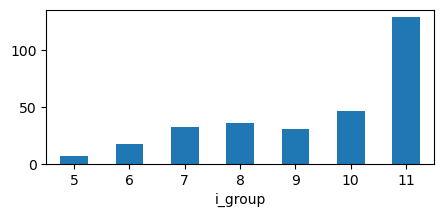

In [129]:
TEMA.i_group.value_counts().sort_index().plot.bar(rot=0, figsize=(5,2));

In [130]:
TEMA[TEMA.i_group == 11]

,tema_type,tema_name,n,p,i,i_group
ana,,,,,,
NIMA'Q_TZ'AQ_TOJIL,topónimo,Nima'a Tz'aq Tojil,1,0.000553,10.820179,11
XE'_B'ALAX,topónimo,Xe' B'alax,1,0.000553,10.820179,11
PETATAYUB',topónimo,Petatayub',1,0.000553,10.820179,11
TZ'UTU_JA,lugar,Tz'utu Ja,1,0.000553,10.820179,11
K'AJB'A_JA,lugar,K'ajb'a Ja,1,0.000553,10.820179,11
...,...,...,...,...,...,...
CHOMI_JA',persona,Chomi Ja',1,0.000553,10.820179,11
TZ'UNUNI_JA',persona,Tz'ununi Ja',1,0.000553,10.820179,11
KAK'IXA_JA',persona,Kak'ixa Ja',1,0.000553,10.820179,11


# Get TYPE

In [131]:
TYPE = TEMA.value_counts('tema_type').to_frame('n')

In [132]:
TYPE

,n
tema_type,
deidad,54
topónimo,54
persona,44
objeto,42
animal,32
oficio,28
linaje,20
lugar,16
grupo de deidades,6


In [243]:
KEEP = TYPE.sort_values('n', ascending=False).head(3).index.tolist()

In [244]:
KEEP

['deidad', 'topónimo', 'persona']

# Get unique PAIRS

Get ANA items that belong to KEEP types.

In [245]:
X = ANA.reset_index().value_counts().to_frame('n').sort_index().reset_index()\
    .merge(TEMA.reset_index()[['ana','tema_type']], on='ana')
X = X[X.tema_type.isin(KEEP)]

In [246]:
X[X.ana.str.match("^TEP")]

,parte,capit,ana,n,tema_type
11,1,1,TEPEW_Q'UKUMATZ,2,deidad
28,1,2,TEPEW_Q'UKUMATZ,7,deidad
464,5,6,TEPEPUL_KQSEIS,1,persona


In [247]:
# X.merge(X, on=['parte','capit'])[['ana_x','ana_y']].value_counts()

In [248]:
PAIRS = X.merge(X, on=['parte','capit'])[['ana_x','ana_y']]\
    .value_counts().to_frame('n')\
    .query("ana_x < ana_y")

In [249]:
PAIRS.loc["TEPEW_Q'UKUMATZ"]

,n
ana_y,
TZ'AQOL,2
TINAMIT_K'ICHE',1
UK'U'X_CHO,1
UK'U'X_KAJ,1
UK'U'X_PALO,1
XPIYAKOK,1


In [250]:
PAIRS['jp'] = PAIRS.n / PAIRS.n.sum()

In [251]:
PAIRS

n        jp
ana_x          ana_y                       
B'ITOL         TZ'AQOL          8  0.004073
JUNAJPU        XB'ALAMQ'E       8  0.004073
JUN_RAQAN      UK'U'X_KAJ       6  0.003055
CH'IPI_KAQULJA RAXA_KAQULJA     5  0.002546
B'ITOL         UK'U'X_KAJ       5  0.002546
...                            ..       ...
JULISNAB'      KAB'RAQAN        1  0.000509
               MAKAMOB'         1  0.000509
               PEK_UL_YA'       1  0.000509
               SAQI_NIM_AQ_SIS  1  0.000509
JAQAWITZ       UK'U'X_ULEW      1  0.000509

[1567 rows x 2 columns]

# Doc ANA matrix

In [252]:
ANAM = ANA.reset_index().value_counts().sort_index().unstack(fill_value=0)

In [253]:
ANAM.head()

ana          ACHAQ'_IB'OY  AJACHE'  AJAL_MES  AJAL_PUJ  AJAL_Q'ANA  \
parte capit                                                          
1     1                 0        0         0         0           0   
      2                 0        0         0         0           0   
      3                 0        0         0         0           0   
      4                 0        0         0         0           0   
      6                 0        0         0         0           0   

ana          AJAL_TOQ'OB  AJAQ_Q'ALEL_NJDOCE  AJAW_AJTZIK_WINAQ  AJAW_AWILIX  \
parte capit                                                                    
1     1                0                   0                  0            0   
      2                0                   0                  0            0   
      3                0                   0                  0            0   
      4                0                   0                  0            0   
      6                0                   0                  0            0   

ana          AJAW_JAQAWITZ  ...  XPIYAKOK  XPURPUWEQ  XUXULIM_JA  XUXULUM_JA  \
parte capit                 ...                                                
1     1                  0  ...         4          0           0           0   
      2                  0  ...         0          0           0           0   
      3                  0  ...         0          0           0           0   
      4                  0  ...         2          0           0           0   
      6                  0  ...         0          0           0           0   

ana          YA'XKANUL  YACHWACH  YAK  YAKI  YAKOLATAM  \
parte capit                                              
1     1              0         0    0     0          0   
      2              0         0    0     0          0   
      3              0         0    0     0          0   
      4              0         0    0     0          0   
      6              0         0    0     0          0   

ana          YAKOLATAM_UTZA'M_POP_SAQLATOL  
parte capit                                 
1     1                                  0  
      2                                  0  
      3                                  0  
      4                                  0  
      6                                  0  

[5 rows x 334 columns]

# Add ANA count to DOC

In [254]:
DOC['n_ana'] = ANAM.sum(1)

In [255]:
DOC

parte_nombre                                       capit_nombre  \
parte capit                                                                   
1     1            NAB'E            ARE' UXE' OJER TZIJ WARAL K'ICHE' UB'I'   
      2            NAB'E                                 ARE UTZIJOXIK WA'E   
      3            NAB'E                      TA XWINAQIR K'U RI ULEW KUMAL   
      4            NAB'E          K'EJE K'UT UTIJTOB'EXIK CHIK WINAQ TZ'AQ,   
      5            NAB'E  K'ATE K'UT UB'IXIK RI' CHI KECH RI E NIK'WACHI...   
      6            NAB'E                          K'ATE K'UT KIK'ISIK CHIK,   
2     1            UKAB'         ARE K'UT XA JUB'IQ' SAQNATANOJ UWACH ULEW,   
      2            UKAB'  K'EJE K'UT XCHIQAB'IJ CHIK TA XKAMIK WUQUB' KA...   
      3            UKAB'               WA'E CHI K'UTE UB'ANOJ CHIK SIPAKNA,   
      4            UKAB'                             ARE CHIK UCH'AKATAJIK,   
      5            UKAB'                    JUN CHI K'UT XCHIQAB'IJ UB'IXIK   
3     1              ROX  ARE CHI K'UT XCHIQAB'IJ CHIK UB'I' KIQAJAW RI ...   
      2              ROX  ARE CHI K'UT XCHIQAB'IJ CHIK KIB'E'IK CHI XIB'...   
      3              ROX  K'ATE PUCH TA XEB'EK JUN JUNAJPU, WUQUB' JUNAJPU.   
      4              ROX                K'ATE K'UT XE'OPONIK PA Q'EQUMA JA,   
      5              ROX                 WA CHI K'UTE UTZIJOXIK JUN Q'APOJ,   
      6              ROX    ARE K'UTE K'O RI UCHUCH JUN B'ATZ', JUN CHOWEN,   
      7              ROX  ARE CHIK XCHIQATZIJOJ KALAXIK JUNAJPU, SXB'ALA...   
      8              ROX   TA XEB'E K'UT CHILA' CHUXE' CHE', Q'ANTE' UB'I';   
      9              ROX               K'ATE K'UT XUKAQ'AT ULA CH'O RI KIK'   
      10             ROX  TA XEPE K'UT NIMA JOK K'U KIB'E RI K'AJOLAB' C...   
      11             ROX                                     TA XEB'E K'UT,   
      12             ROX                 K'ATE K'UT TA XE'OK PA Q'EQUMA JA,   
      13             ROX  ARE K'UT WA'E KINAB'AL, KIKAMIK JUNAJPU, XB'AL...   
      14             ROX  K'ATE PUCH URAYINIK, UMALINIK PU KIK'UX AJAWAB...   
4     1             UKAJ  WA'E K'UT UTIKERIK TA XNA'OJIX WINAQ, TA XTZUK...   
      2             UKAJ        WA'E KIB'I NAB'E WINAQ XETZ'AQIK, XEB'ITIK:   
      3             UKAJ            ARE K'UT UXE' QECH, RI OJ K'ECHE' WINAQ   
      4             UKAJ                         ARE K'UT UB'I' JUYUB' WA',   
      5             UKAJ    WA'E K'UTE' USAQIRIK, UWACHINIK PUCH Q'IJ, IK',   
      6             UKAJ                              WA K'UTE' KIK'ATONIK,   
      7             UKAJ  WA'E UTIKARIK CHIK RELEQ'AXIK WINAQ, AMAQ' kum...   
      8             UKAJ                   ARE K'U WA' UK'AMIK UNA'OJ AMAQ'   
      9             UKAJ                                 K'ATE PUCH XEB'EK,   
      10            UKAJ           WA'E K'UTE KIMOLOWIK KIB' KONOJEL AMAQ',   
      11            UKAJ  ARE CHIK WI XCHIQAB'IJ CHIK KIKAMIK B'alam Kit...   
5     1              RO'                    K'ATE PUCH TA XKIK'UXLAJ KIB'IK   
      2              RO'                            TA XE'UL CHI K'U CHIRI'   
      3              RO'        WA'E K'UTE KIB'I' AJAWAB' CHUWACH KAWIQIB'.   
      4              RO'       ARE CHI K'U AJAWAB' WA' CHUWACH NIJA'IB'AB':   
      5              RO'                     ARE CHI K'UT AJAW K'ICHE' WA'.   
      6              RO'     KA'IB' CHINAMIT CHI NAY PUCH SAQIKIB' AJAWAB':   
      7              RO'           WA' CHI K'UTE KIB'I' CHIK UWAQ LE' AJAW,   
      8              RO'    ARE K'UT XCHIQAB'IJ CHIK UB'I' ROCHOCH KAB'AWIL   
      9              RO'  ARE CHI K'UT XCHIQACHOLO ULE'EL AJAWAB' RUK' K...   
      10             RO'               ARE CHI XCHIQAB'IJ CHIK RE CHINAMIT,   
      11             RO'   ARE UB'INA'M WI B'ELEJEB' CHINAMIT CHI KAWIQIB',   
      12             RO'                          WA K'UTE RECH NIJA'IB'AB'   
      13             RO'      ARE CHIK XCHIQAB'IJ RAJAWAL JUJU

# CORR

In [256]:
CORR = ANAM.corr().stack().sort_values(ascending=False).to_frame('r')
CORR.index.names = ['ana_x','ana_y']
CORR = CORR.query("ana_x < ana_y")

In [257]:
PAIRS['r'] = CORR

In [258]:
PAIRS[PAIRS.r == 1]

n        jp    r
ana_x          ana_y                           
CH'IPI_KAQULJA RAXA_KAQULJA    5  0.002546  1.0
ALOM           K'AJOLOM        5  0.002546  1.0
AJAL_Q'ANA     CH'AMIYA_JOLOM  2  0.001018  1.0
IXPUCH'        IXTAJ           2  0.001018  1.0
AJAW_JAQAWITZ  AJAW_LOLMET     2  0.001018  1.0
...                           ..       ...  ...
JUMETA_JA      Q'UMARKAJ       1  0.000509  1.0
               SOR_OBISPO      1  0.000509  1.0
JULISNAB'      JUNAJPU_JUYUB'  1  0.000509  1.0
               MAKAMOB'        1  0.000509  1.0
               PEK_UL_YA'      1  0.000509  1.0

[416 rows x 3 columns]

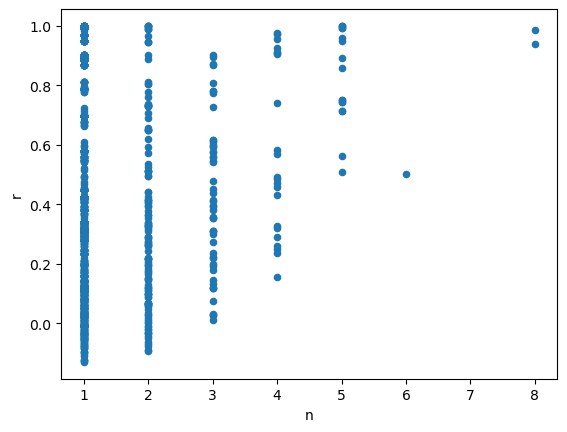

In [259]:
PAIRS.plot.scatter('n', 'r');

# Graph

Get co-occurring pairs.

In [260]:
edge_weight = 'r' # r, n, jp

In [261]:
thresh = 2

In [262]:
P = PAIRS[PAIRS.n >= thresh]

In [263]:
P.sort_values('n')

n        jp         r
ana_x           ana_y                                 
TEPEW_Q'UKUMATZ TZ'AQOL          2  0.001018  0.172249
K'AJOLOM        RAXA_KAQULJA     2  0.001018  0.650272
IQ'I_B'ALAM     TINAMIT_K'ICHE'  2  0.001018  0.325110
JAQAWITZ        TINAMIT_K'ICHE'  2  0.001018  0.261146
                TULÁN            2  0.001018  0.811093
...                             ..       ...       ...
ALOM            K'AJOLOM         5  0.002546  1.000000
JUN_KAME'       WUQUB'_KAME'     5  0.002546  0.893572
JUN_RAQAN       UK'U'X_KAJ       6  0.003055  0.503704
JUNAJPU         XB'ALAMQ'E       8  0.004073  0.938669
B'ITOL          TZ'AQOL          8  0.004073  0.985479

[233 rows x 3 columns]

In [264]:
len(P)

233

## NetworkX

In [265]:
import networkx as nx
import matplotlib.pyplot as plt

In [266]:
G = nx.Graph()

In [267]:
_ = P.reset_index().apply(lambda x: G.add_edge(x.ana_x, x.ana_y, weight=x[edge_weight]), axis=1)

In [268]:
TEMA['degree'] = pd.Series(dict(G.degree())).sort_values()

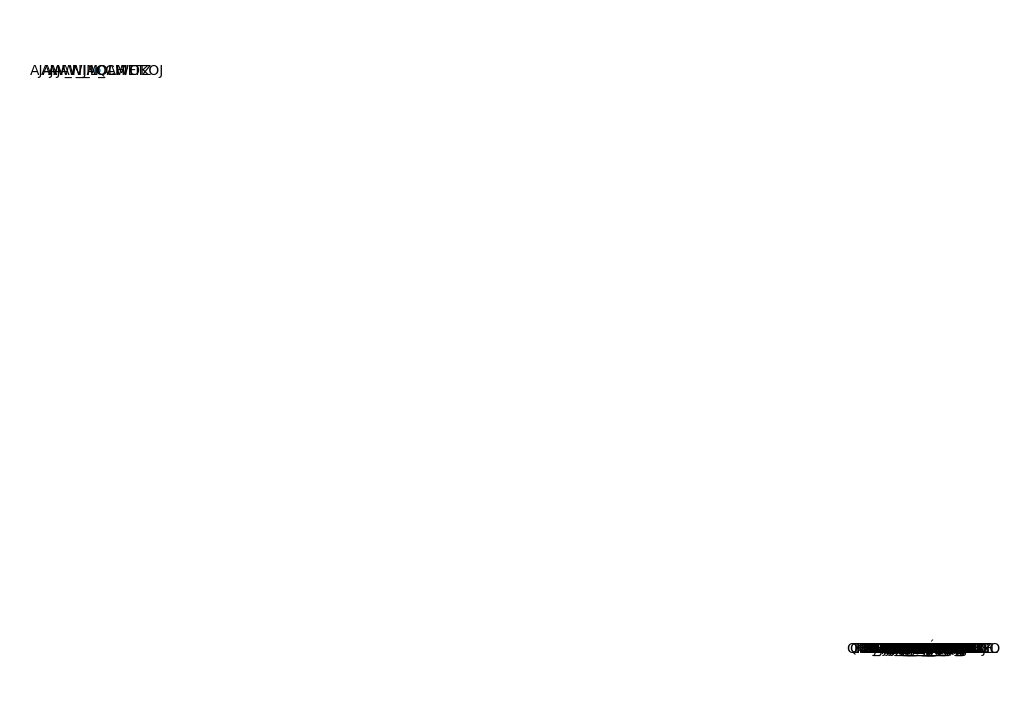

In [269]:
plt.figure(figsize=(10, 7))
# pos = nx.spring_layout(G, seed=42)
# pos = nx.circular_layout(G)
pos = nx.spectral_layout(G)
edges = G.edges(data=True)
weights = [edge[2]['weight'] for edge in edges]  # Extract weights
nx.draw(
    G, pos, with_labels=True, node_size=10, font_size=10,
    edge_color=weights, edge_cmap=plt.cm.Blues, width=[w/2 for w in weights]
)
plt.show()

## PyVis

In [270]:
from pyvis.network import Network

net = Network(notebook=True, 
    height="800px", width="100%", 
    bgcolor="#ffffff", font_color="black", 
    cdn_resources='remote')

# Add nodes and edges with styling
degree_dict = dict(G.degree())

for node, degree in degree_dict.items():
    net.add_node(node, label=node, size=degree, color="blue")

In [271]:
for idx, row in P.reset_index().iterrows():
    try:
        net.add_edge(row["ana_x"], row["ana_y"], value=row["n"], width=row["n"]/2)
    except AssertionError as e:
        print(e)
        print(row)
        pass
net.show("force_graph.html")

force_graph.html


## GraphViz

In [272]:
# Generate DOT file content
dot_lines = ["graph G {"]
dot_lines.append('  graph [overlap=true, splines=true];')  # Improve readability
dot_lines.append('  node [shape=plaintext, style=filled, fillcolor=lightblue, fontname="Helvetica"];')

In [273]:
# Add edges with weights as labels
for _, row in P.reset_index().iterrows():
    dot_lines.append(f'  "{row["ana_x"]}" -- "{row["ana_y"]}" [label="{row["n"]}"];')
dot_lines.append("}")

In [274]:
# Save to file
dot_filename = "graph"
with open(dot_filename + '.dot', "w") as f:
    f.write("\n".join(dot_lines))
print(f"DOT file saved as {dot_filename}")

DOT file saved as graph


In [275]:
!dot -Tpng {dot_filename}.dot -o {dot_filename}.png

## Pygraphviz

In [ ]:
# AG = pgv.AGraph(name='G')
# _ = P.reset_index().apply(lambda x: AG.add_edge(x.ana_x, x.ana_y, weight=x.r), axis=1)
# AG.write("pygraphviz.dot")

In [ ]:
# print(AG)

# Play

In [187]:
ALL = []
for a, b in PAIRS.index.tolist():
    ALL.append(a)
    ALL.append(b)

In [189]:
set(ALL)

{"ACHAQ'_IB'OY",
 "AJACHE'",
 'AJAL_MES',
 'AJAL_PUJ',
 "AJAL_Q'ANA",
 "AJAL_TOQ'OB",
 'AJAW_AJTZIK_WINAQ',
 'AJAW_AWILIX',
 'AJAW_JAQAWITZ',
 "AJAW_K'ICHE'",
 "AJAW_K'OTUJA_NJONCE",
 'AJAW_LOLMET',
 "AJAW_NIM_CH'OKOJ",
 "AJAW_Q'ALEL",
 "AJAW_Q'ALEL_K'AMJA",
 'AJAW_XIK',
 'AJPATAN',
 'AJPOP',
 "AJPOP_K'AMJA",
 "AJQ'UKUMATZ",
 'AJRAXA_LAQ',
 'AJRAXA_TZEL',
 'AJTOJIL',
 "AJTZ'IKINA_JA",
 'AJTZIK_WINAQ',
 'AJTZIK_WINAQ_AJAW',
 "AJ_KAB'RAQAN",
 'ALOM',
 "AMAQ'_TAM",
 "AMAQ'_UQ'IN_K'AT",
 'AQ',
 'AQAJ',
 'ASTAPULUL',
 'AWILIX',
 "B'ALAM",
 "B'ALAM_AQ'AB'",
 "B'ALAM_K'ONACHE'_KQTRES",
 "B'ALAM_KI'TZE'",
 "B'AQ",
 "B'ATE",
 "B'ELEJEB'_KEJ_NJCUATRO",
 "B'ITOL",
 "B'OQOTAJINAQ_SANAYEB'",
 "CH'ABI_Q'AQ'",
 "CH'AMIYA_JOLOM",
 "CH'IPI_KAQULJA",
 "CH'O",
 'CHAAJ',
 'CHAMALKAN',
 'CHAMCHAM',
 'CHAYIM_JA',
 'CHIMALMAT',
 'CHITEMAJ',
 'CHIYOM',
 "CHI_CHAQ'",
 "CHI_ISMACHI'",
 'CHI_JUNAJPU',
 "CHI_K'IX",
 "CHI_PIXAB'",
 "CHI_Q'AQ'",
 "CHI_RATINIB'AL_TOJIL",
 "CHOLOCHIK_AB'AJ",
 "CHOMI_JA'",
 'CHULIMAL'